# Chapter 1.1. 강화학습이란 무엇인가 — 실습 노트북

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/SuminHan/book-ml/blob/main/notebooks/ml2/chapter01_1_rl_roadmap.ipynb)

책 본문: [1.1 강화학습이란 무엇인가, 그리고 이번 학기 로드맵](https://smhanlab.com/book-ml/kor/ml2/chapter01/1.html)

이 노트북은 1.1절의 세 가지 핵심을 **실행**해본다.

1. **에이전트–환경 루프**: Gymnasium으로 `reset`/`step`을 돌리고, 이산/연속 행동 공간을 비교한다.
2. **보상 vs 리턴**: 할인율 \(\gamma\)가 "미래의 보상"에 얼마나 영향을 주는지 수치로 본다.
3. **탐험 vs 활용**: 순수 탐욕(\(\varepsilon=0\))이 "가장 좋은 팔을 영영 못 만나는" 함정에 빠지는 것을 재현한다.


## 1. 강화학습 루프: 에이전트와 환경

어떤 Gymnasium 환경이든 "현재 상태를 관측하고(`reset`), 행동을 하나 취하면(`step`)
다음 상태·보상·종료 여부가 돌아온다"는 똑같은 인터페이스를 따른다.

CartPole(막대 균형)과 Pendulum(막대 올리기)을 비교하면 **이산 vs 연속**
행동 공간의 차이가 바로 보인다 — 이 차이가 Chapter 9(DQN)과
Chapter 10~11(정책기반)의 알고리즘 선택을 가른다.


In [1]:
import numpy as np
import gymnasium as gym

for name in ["CartPole-v1", "Pendulum-v1"]:
    env = gym.make(name)
    obs, _ = env.reset(seed=0)
    print(f"[{name}]")
    print(f"  초기 상태 obs = {np.round(obs, 3)}   (shape {obs.shape})")
    print(f"  상태 공간: {env.observation_space}")
    print(f"  행동 공간: {env.action_space}")
    a = env.action_space.sample()
    obs2, r, term, trunc, _ = env.step(a)
    print(f"  무작위 행동 a={a} -> reward={r:.3f}, terminated={term}")
    env.close()
    print()


[CartPole-v1]
  초기 상태 obs = [ 0.014 -0.023 -0.046 -0.048]   (shape (4,))
  상태 공간: Box([-4.8               -inf -0.41887903        -inf], [4.8               inf 0.41887903        inf], (4,), float32)
  행동 공간: Discrete(2)
  무작위 행동 a=1 -> reward=1.000, terminated=False

[Pendulum-v1]
  초기 상태 obs = [ 0.652  0.758 -0.46 ]   (shape (3,))
  상태 공간: Box([-1. -1. -8.], [1. 1. 8.], (3,), float32)
  행동 공간: Box(-2.0, 2.0, (1,), float32)
  무작위 행동 a=[1.7261086] -> reward=-0.765, terminated=False



## 2. 보상(reward) vs 리턴(return)

에이전트가 최대화하는 것은 **한 스텝의 보상** \(R_t\)가 아니라
**할인된 미래 보상 합**, 즉 리턴이다.

\[G_t = \sum_{k=0}^{\infty} \gamma^k R_{t+k}\]

할인율 \(\gamma \in [0,1)\)은 "지금의 1이 10스텝 뒤의 1보다 비싸다"는
금융의 시간가치와 같은 직관을 공식화한 것이다. 아래에서 \(\gamma\)가
리턴을 얼마나 줄이는지 두 가지 예로 확인한다.


In [2]:
def discounted_return(rewards, gamma):
    G, g = 0.0, 1.0
    for r in rewards:
        G += g * r
        g *= gamma
    return G

# 예 1: 매 스텝 보상 1 (50스텝)
print("예 1 — 매 스텝 reward=1, 50스텝:")
for g in (0.0, 0.5, 0.9, 0.99):
    closed = (1 - g**50)/(1-g) if g < 1 else 50.0
    print(f"  gamma={g:.2f}: G = {discounted_return([1.0]*50, g):8.4f}   (수식 (1-g^50)/(1-g) = {closed:.4f})")
print(f"  무한급수의 한계 1/(1-0.99) = {1/(1-0.99):.1f}")

# 예 2: 희박 보상 — 100스텝 중 마지막 스텝에만 보상 10
print("\n예 2 — 마지막(99스텝)에만 reward=10, 나머지 0:")
sparse = [0.0]*99 + [10.0]
for g in (0.5, 0.9, 0.99):
    print(f"  gamma={g:.2f}: G = {discounted_return(sparse, g):8.4f}   (보상 자체는 10)")
print("  -> gamma가 작을수록 '멀리 있는' 보상은 거의 0으로 디스카운트된다.")


예 1 — 매 스텝 reward=1, 50스텝:
  gamma=0.00: G =   1.0000   (수식 (1-g^50)/(1-g) = 1.0000)
  gamma=0.50: G =   2.0000   (수식 (1-g^50)/(1-g) = 2.0000)
  gamma=0.90: G =   9.9485   (수식 (1-g^50)/(1-g) = 9.9485)
  gamma=0.99: G =  39.4994   (수식 (1-g^50)/(1-g) = 39.4994)
  무한급수의 한계 1/(1-0.99) = 100.0

예 2 — 마지막(99스텝)에만 reward=10, 나머지 0:
  gamma=0.50: G =   0.0000   (보상 자체는 10)
  gamma=0.90: G =   0.0003   (보상 자체는 10)
  gamma=0.99: G =   3.6973   (보상 자체는 10)
  -> gamma가 작을수록 '멀리 있는' 보상은 거의 0으로 디스카운트된다.


## 3. 탐험 vs 활용: 순수 탐욕의 함정

진짜 평균 보상이 **arm 0 = 1.0, arm 1 = 2.0**(arm 1이 진짜 최선)인
2-팔 밴딧을 200번 당긴다. 두 전략을 **같은 무작위 시드(seed=1)**에서 비교한다.

- **\(\varepsilon=0\)(순수 탐욕)**: 매번 "지금까지 추정치가 가장 큰" 팔만 당긴다.
- **\(\varepsilon=0.1\)**: 10% 확률로 무작위 팔을 당긴다(탐험).

추정치는 "관찰한 보상의 평균"으로 갱신한다(2.1절의 증분 갱신식).


In [3]:
import random

def bandit(true_means, eps, steps, seed):
    random.seed(seed)
    k = len(true_means)
    Q = [0.0]*k; N = [0]*k
    cum = 0.0; cum_curve = []
    for t in range(steps):
        a = random.randrange(k) if random.random() < eps else max(range(k), key=lambda i: Q[i])
        r = random.gauss(true_means[a], 1.0)   # 실제 보상: 평균 true_means[a], 잡음 std=1
        N[a] += 1
        Q[a] += (r - Q[a]) / N[a]              # 증분 갱신 = 관찰 보상의 평균
        cum += r
        cum_curve.append(cum)
    return Q, N, cum_curve

true = [1.0, 2.0]   # arm 1이 진짜 최선
Q0, N0, curve0 = bandit(true, 0.0, 200, seed=1)   # 순수 탐욕
Q1, N1, curve1 = bandit(true, 0.1, 200, seed=1)   # eps-greedy

print("진짜 평균: arm0=1.0, arm1=2.0 (arm 1이 최선), 200회, seed=1")
print()
print(f"  epsilon=0.0 : 시도 횟수 N={N0}")
print(f"               최선 팔(arm1) 시도 횟수 = {N0[1]}회")
print(f"               고른 팔 = arm {int(max(range(2), key=lambda i: Q0[i]))}  (최선 arm1인가? {max(range(2), key=lambda i: Q0[i])==1})")
print(f"               누적 보상 = {curve0[-1]:.1f}   (1회 평균 {curve0[-1]/200:.3f})")
print()
print(f"  epsilon=0.1 : 시도 횟수 N={N1}")
print(f"               최선 팔(arm1) 시도 횟수 = {N1[1]}회")
print(f"               고른 팔 = arm {int(max(range(2), key=lambda i: Q1[i]))}  (최선 arm1인가? {max(range(2), key=lambda i: Q1[i])==1})")
print(f"               누적 보상 = {curve1[-1]:.1f}   (1회 평균 {curve1[-1]/200:.3f})")


진짜 평균: arm0=1.0, arm1=2.0 (arm 1이 최선), 200회, seed=1

  epsilon=0.0 : 시도 횟수 N=[200, 0]
               최선 팔(arm1) 시도 횟수 = 0회
               고른 팔 = arm 0  (최선 arm1인가? False)
               누적 보상 = 189.7   (1회 평균 0.949)

  epsilon=0.1 : 시도 횟수 N=[88, 112]
               최선 팔(arm1) 시도 횟수 = 112회
               고른 팔 = arm 1  (최선 arm1인가? True)
               누적 보상 = 313.1   (1회 평균 1.566)


**결과를 읽어보자.** 순수 탐욕(\(\varepsilon=0\))은 첫 번째 시도에서 arm 0의
보상이 *운이 나쁘게* 낮게 나오자, 그 뒤 200번 내내 arm 0만 당긴다 —
진짜 최선인 arm 1을 **단 한 번도** 시도하지 못한다. 같은 시드에서
\(\varepsilon=0.1\)만 섞어주면 arm 1을 100회 이상 시도해 진짜 최선을
발견한다.

이것이 "탐험에도 비용이 있다(\(\varepsilon>0\)면 나쁜 팔도 당긴다)
하지만 탐험이 없으면 최선을 영영 놓친다(\(\varepsilon=0\))"는 딜레마의
구체적 예다. Chapter 2에서 이 \(\varepsilon\)를 **decay**시키거나
UCB(불확실성 활용)로 대체하는 방법까지 다룬다.


## 4. 시각화

(1) ε-greedy의 누적 보상 곡선, (2) 4-팔 밴딧에서 ε-greedy가 어떻게
최선 팔로 수렴하는지 그린다.


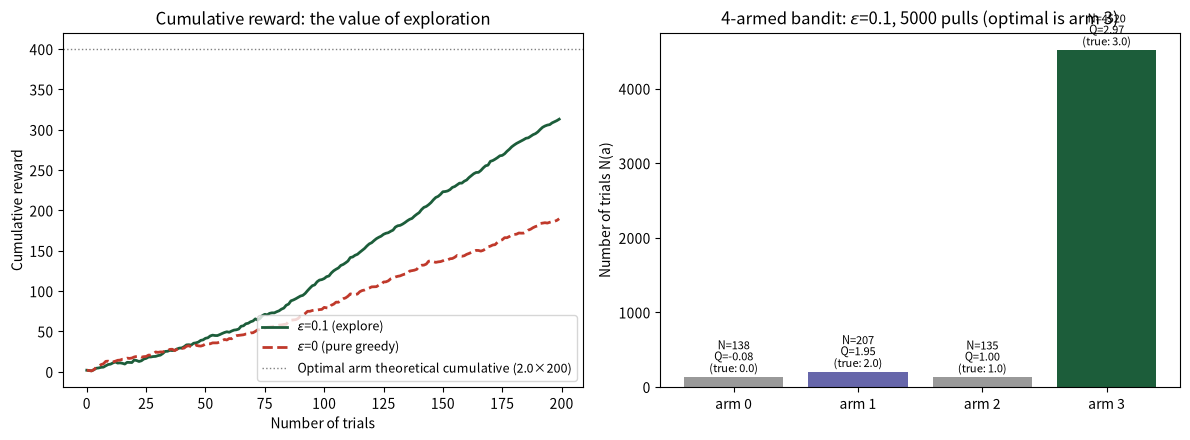

최선 팔(arm 3)에 대한 추정 Q = 2.968  (진짜 3.0)


In [4]:
import matplotlib.pyplot as plt
plt.rcParams["font.family"] = "Noto Sans CJK KR"
plt.rcParams["axes.unicode_minus"] = False

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# (1) eps-greedy vs pure-greedy 누적 보상
ax = axes[0]
ax.plot(curve1, label=r"$\varepsilon$=0.1 (explore)", color="#1c5d3a", lw=2)
ax.plot(curve0, label=r"$\varepsilon$=0 (pure greedy)", color="#c0392b", lw=2, ls="--")
ax.axhline(2.0*200, color="gray", lw=1, ls=":", label="Optimal arm theoretical cumulative (2.0×200)")
ax.set_title("Cumulative reward: the value of exploration")
ax.set_xlabel("Number of trials"); ax.set_ylabel("Cumulative reward")
ax.legend(loc="lower right", fontsize=9)

# (2) 4-팔 밴딧에서 epsilon-greedy의 수렴
def bandit4(true, eps, steps, seed):
    random.seed(seed); k=len(true)
    Q=[0.0]*k; N=[0]*k
    for t in range(steps):
        a = random.randrange(k) if random.random()<eps else max(range(k), key=lambda i:Q[i])
        r = random.gauss(true[a],1.0); N[a]+=1; Q[a]+=(r-Q[a])/N[a]
    return Q, N
Q4, N4 = bandit4([0.0,2.0,1.0,3.0], 0.1, 5000, seed=42)
ax = axes[1]
bars = ax.bar(range(4), N4, color=["#999","#66a","#999","#1c5d3a"])
for i,(n,q,t) in enumerate(zip(N4,Q4,[0.0,2.0,1.0,3.0])):
    ax.text(i, n+60, f"N={n}\nQ={q:.2f}\n(true: {t})", ha="center", fontsize=8)
ax.set_xticks(range(4)); ax.set_xticklabels(["arm 0","arm 1","arm 2","arm 3"])
ax.set_title(r"4-armed bandit: $\varepsilon$=0.1, 5000 pulls (optimal is arm 3)")
ax.set_ylabel("Number of trials N(a)")

plt.tight_layout()
plt.show()
print("최선 팔(arm 3)에 대한 추정 Q =", round(Q4[3],3), " (진짜 3.0)")


## 정리: 이번 절에서 확인한 것

- **에이전트–환경 루프** — `reset`/`step` 인터페이스로 어떤 환경이든
  같은 코드로 돌린다. CartPole(이산 2행동)과 Pendulum(연속 행동)은
  알고리즘 선택(Q-테이블 가능/불가)까지 바꾼다.
- **보상 vs 리턴** — 에이전트가 최대화하는 것은 할인된 보상 합 \(G_t\)다.
  \(\gamma\)가 작으면 "먼 미래의 보상"은 거의 0이 된다.
- **탐험 vs 활용** — \(\varepsilon=0\)은 단 한 번의 나쁜 운으로 최선을
  영영 놓칠 수 있다. 탐험(\(\varepsilon>0\))은 비용이지만 필수다.

이 세 가지가 Chapter 2(멀티암 밴딧)부터 16(캡스톤)까지의 모든
강화학습 알고리즘의 뼈대다. 다음 절(1.2)은 신경망 미니 리뷰,
1.3절은 Gymnasium 실습 환경 세팅이다.
